# Büchi Automata & Kripke Models — Graphviz Visualization

High-quality diagrams using **Graphviz** (DOT language). Graphviz produces publication-quality output with excellent self-loop handling and hierarchical layout.

In [2]:
%matplotlib inline
import os, sys
import IPython.display as display

_d = os.path.abspath(os.getcwd())
while _d != os.path.dirname(_d) and not os.path.isdir(os.path.join(_d, 'tutorials', 'buchi')):
    _d = os.path.dirname(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)

from tutorials.buchi import BuchiAutomaton, KripkeModel
from tutorials.buchi.visualization_graphviz import draw
print('imports OK')

imports OK


## 1. Büchi automaton

Accepting **`a·b·(a·b·c)ᵒ̬`** — prefix `ab`, then loop `abc` forever.

witness: {a}{b}·({a}{b}{c})ω


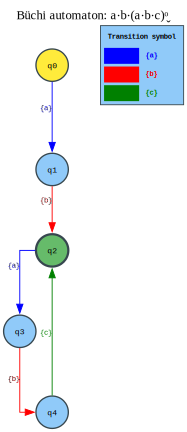

In [3]:
buchi = BuchiAutomaton()
buchi.add_initial_state('q0')
buchi.add_transition('q0', {'a'}, 'q1')
buchi.add_transition('q1', {'b'}, 'q2')
buchi.add_accepting_state('q2')
buchi.add_transition('q2', {'a'}, 'q3')
buchi.add_transition('q3', {'b'}, 'q4')
buchi.add_transition('q4', {'c'}, 'q2')

res = buchi.check_emptiness()
print('witness:', res.witness)

g = draw(buchi, title='Büchi automaton: a·b·(a·b·c)ᵒ̬',
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors={'{a}': 'blue', '{b}': 'red', '{c}': 'green'},
         legend_title='Transition symbol')
display.SVG(g.pipe(format='svg'))

## 2. Kripke model

A Kripke model `(S, →, L)` with propositions holding at states.

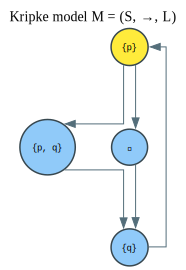

In [4]:
kripke = KripkeModel()
kripke.add_initial_state('s0', {'p'})
kripke.add_state('s1', {'p', 'q'})
kripke.add_state('s2', {'q'})
kripke.add_state('s3', set())

kripke.add_transition('s0', 's1')
kripke.add_transition('s1', 's2')
kripke.add_transition('s2', 's0')
kripke.add_transition('s0', 's3')
kripke.add_transition('s3', 's2')

g = draw(kripke, title='Kripke model M = (S, →, L)',
         node_propositions=kripke.labeling, show_edge_labels=False, use_xlabels=False)
display.SVG(g.pipe(format='svg'))

## 3. Self-loops — infinitely many 'a's

Graphviz renders self-loops beautifully as arcs on the node.

witness: {a}·({a})ω


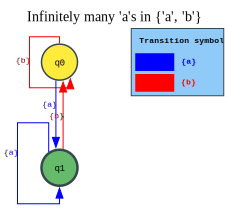

In [5]:
inf_a = BuchiAutomaton()
inf_a.add_initial_state('q0')
inf_a.add_accepting_state('q1')

inf_a.add_transition('q0', {'a'}, 'q1')
inf_a.add_transition('q0', {'b'}, 'q0')  # self-loop
inf_a.add_transition('q1', {'a'}, 'q1')  # self-loop
inf_a.add_transition('q1', {'b'}, 'q0')

res = inf_a.check_emptiness()
print('witness:', res.witness)

g = draw(inf_a, title="Infinitely many 'a's in {'a', 'b'}",
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         edge_colors={'{a}': 'blue', '{b}': 'red'},
         legend_title='Transition symbol')
display.SVG(g.pipe(format='svg'))

## 4. Intersection — both 'a' and 'b' infinitely often

The intersection of two automata: one accepting infinitely many 'a's, another accepting infinitely many 'b's. The product automaton accepts words with *both* 'a' and 'b' infinitely often.

The product state space is `Q₁ × Q₂ × {1, 2}` with a tracking bit that toggles between the two accepting sets. The accepting states are those where bit=1 (watching for `a`).

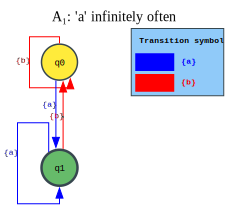

In [6]:
from tutorials.buchi import intersect

def inf_symbol(symbol, other):
    """Automaton accepting 'symbol' infinitely often over alphabet {symbol, other}."""
    a = BuchiAutomaton()
    a.add_initial_state('s0')
    a.add_accepting_state('s1')
    a.add_transition('s0', {symbol}, 's1')
    a.add_transition('s0', {other}, 's0')  # self-loop
    a.add_transition('s1', {symbol}, 's1')  # self-loop (accepting)
    a.add_transition('s1', {other}, 's0')
    return a

a_inf = inf_symbol('a', 'b')      # 'a' infinitely often
b_inf = inf_symbol('b', 'a')      # 'b' infinitely often

g1 = draw(a_inf, title="A₁: 'a' infinitely often",
          initial_color='#ffeb3b', accepting_color='#66bb6a',
          edge_colors={'{a}': 'blue', '{b}': 'red'},
          legend_title='Transition symbol')
display.SVG(g1.pipe(format='svg'))

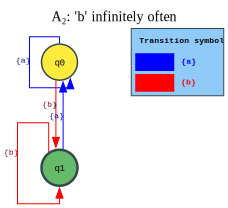

In [7]:
g2 = draw(b_inf, title="A₂: 'b' infinitely often",
          initial_color='#ffeb3b', accepting_color='#66bb6a',
          edge_colors={'{a}': 'blue', '{b}': 'red'},
          legend_title='Transition symbol')
display.SVG(g2.pipe(format='svg'))

Product empty: False
Witness: {a}·({b}{a})ω


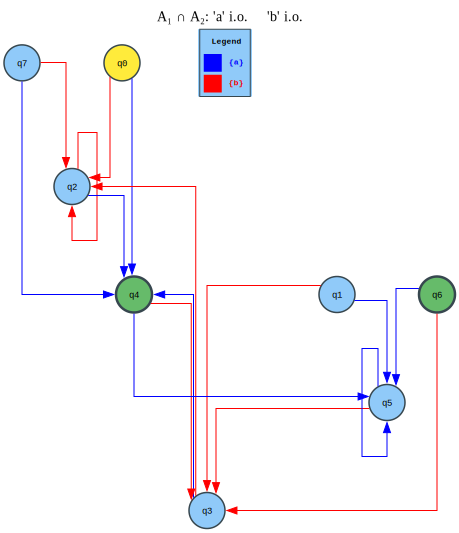

In [8]:
product = intersect(a_inf, b_inf)

res = product.check_emptiness()
print(f'Product empty: {res.is_empty}')
print(f'Witness: {res.witness}')

g = draw(product, title="A₁ ∩ A₂: 'a' i.o. ∧ 'b' i.o.",
         initial_color='#ffeb3b', accepting_color='#66bb6a',
         size='14,10', nodesep=0.8, ranksep=1.0,
         show_edge_labels=False,
         edge_colors={'{a}': 'blue', '{b}': 'red'})
display.SVG(g.pipe(format='svg'))

## 5. Kripke model from a NuPlan lane graph

A **Kripke model** `M = (S, →, L)` is the natural way to represent a road-network graph for temporal reasoning:
- **States** `S` = lane segments and lane connectors near the ego vehicle.
- **Transitions** `→` = the `outgoing_edges` connectivity in the NuPlan map.
- **Labelling** `L` is supplied by a user-defined function `node_to_props(node_id) → set[str]` that inspects each map object and returns the atomic propositions true there.

Propositions used here:

| Proposition | Meaning |
|-------------|---------|
| `lane` | Regular lane segment |
| `connector` | Lane connector (crosses an intersection) |
| `ego` | Ego vehicle's current lane/connector |
| `fork` | More than one outgoing edge (choice point) |

In [ ]:
import networkx as nx
from nuplan.common.actor_state.state_representation import Point2D
from nuplan.common.maps.nuplan_map.map_factory import NuPlanMapFactory, get_maps_db

from tutorials.buchi.nuplan_graph import load_nuplan_subgraph
from tutorials.buchi.nuplan_scenarios import get_scenarios

# ── Load scenario & map once ─────────────────────────────────────────────────
scenario = get_scenarios(split='mini', scenario_types=['accelerating_at_traffic_light'])[1]
map_factory = NuPlanMapFactory(
    get_maps_db(map_root=scenario.map_root, map_version=scenario.map_version))
nuplan_map = map_factory.build_map_from_name(scenario.map_api.map_name)

ego_state = scenario.get_ego_state_at_iteration(0)
ego_point = Point2D(ego_state.rear_axle.x, ego_state.rear_axle.y)

# ── Example 1: radius = 200 m, depth = 10 ────────────────────────────────────
small_G, object_map, object_types, ego_id = load_nuplan_subgraph(nuplan_map, ego_point, radius=200, depth_limit=10)
print(f"Subgraph: {small_G.number_of_nodes()} nodes, {small_G.number_of_edges()} edges")
print(f"Ego node: {ego_id}")

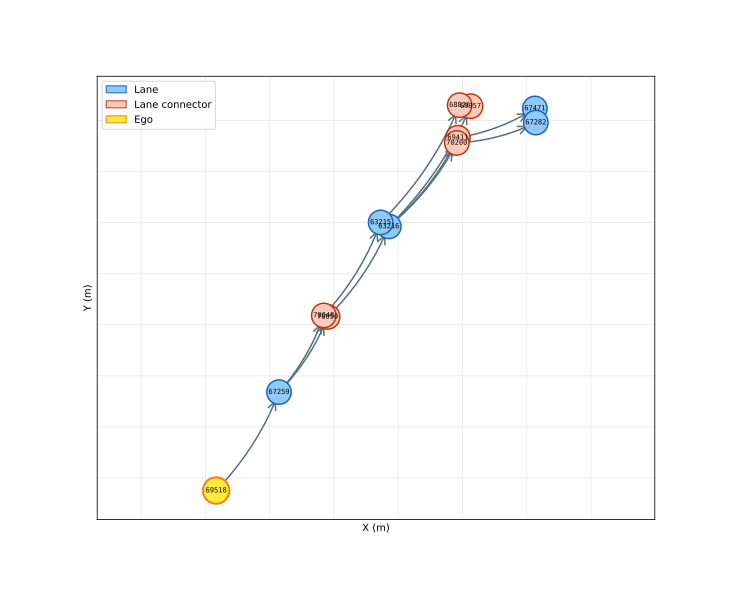

In [11]:
from tutorials.buchi.nuplan_graph import nuplan_pos, draw_nuplan_subgraph

pos = nuplan_pos(small_G, object_map)
draw_G = small_G.subgraph(pos.keys()).copy()

draw_nuplan_subgraph(draw_G, pos, object_types, ego_id,
                     title='NuPlan subgraph (NetworkX) — ego neighbourhood')

Kripke model: 12 states, 11 transitions

Propositions per state:
  63215: ['lane']
  63216: ['fork', 'lane']
  67259: ['fork', 'lane']
  67282: ['lane']
  67471: ['lane']
  68826: ['connector']
  69357: ['connector']
  69411: ['connector']
  69518: ['connector', 'ego']  [initial]
  70048: ['connector']
  70050: ['connector']
  70200: ['connector']


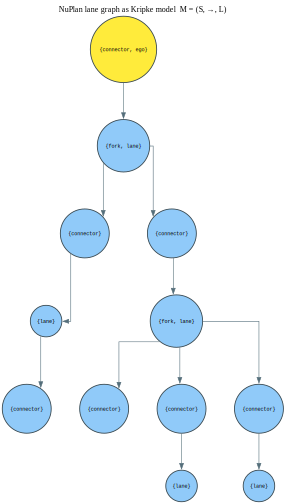

In [12]:
# ── User-defined proposition map ─────────────────────────────────────────────
def node_to_props(node_id: str) -> set:
    """
    Map a NuPlan lane-graph node ID to the atomic propositions holding there.

    This is the user-supplied labelling function L : S → 2^AP for the Kripke model.
    Modify or extend this function to encode any road-level predicates of interest.
    """
    props = set()
    props.add(object_types.get(node_id, 'unknown'))   # 'lane' or 'connector'
    if node_id == ego_id:
        props.add('ego')
    if small_G.out_degree(node_id) > 1:
        props.add('fork')
    return props

# ── Build Kripke model from the NuPlan subgraph ──────────────────────────────
kripke_nuplan = KripkeModel()

for node in small_G.nodes():
    props = node_to_props(node)
    if node == ego_id:
        kripke_nuplan.add_initial_state(node, props)
    else:
        kripke_nuplan.add_state(node, props)

for src, dst in small_G.edges():
    kripke_nuplan.add_transition(src, dst)

print(f"Kripke model: {len(kripke_nuplan.states)} states, "
      f"{sum(len(v) for v in kripke_nuplan._transitions.values())} transitions")
print("\nPropositions per state:")
for s in sorted(kripke_nuplan.states, key=str):
    marker = "  [initial]" if s in kripke_nuplan.initial_states else ""
    print(f"  {s}: {sorted(kripke_nuplan.labeling[s])}{marker}")

# ── Visualize ────────────────────────────────────────────────────────────────
g = draw(kripke_nuplan,
         title='NuPlan lane graph as Kripke model  M = (S, →, L)',
         node_propositions=node_to_props,
         show_edge_labels=False,
         use_xlabels=False,
         initial_color='#ffeb3b',
         size='10,7', nodesep=0.7, ranksep=0.9)
display.SVG(g.pipe(format='svg'))

## 6. GPVW intermediate construction — `old`, `now`, `next` sets

The `ltl_to_buchi_gpvw` function now uses the **Gerth–Peled–Vardi–Wolper (GPVW) on-the-fly** algorithm.  Instead of enumerating the closure and elementary sets upfront, GPVW builds states incrementally by expanding *sets of subformula obligations*:

| Set | Meaning |
|-----|---------|
| **old** | Formulas already processed at this state — they hold "right now" |
| **now** | Formulas yet to be processed at this step (empty for finalized states) |
| **nxt** | Formulas deferred to the **next** time step |

Two nodes with the same `old` and `nxt` are **merged** (they represent the same local theory).  The result is a Generalized Büchi Automaton (GBA); one accepting set per `U` sub-formula ensures every Until promise is eventually fulfilled.

Each diagram below shows the **finalized GPVW nodes** (now = ∅) for the four simple LTL formulas from Section 6.  Initial states are yellow, accepting states have a double border and green header.

In [13]:
from tutorials.buchi import ltl_to_buchi_gpvw, Var, F, G, U

from tutorials.buchi.gpvw_ltl_to_buchi import (
    ltl_to_gba_gpvw, to_nnf, formula_untils, INIT, Atom, Not as NNFNot,
)
from tutorials.buchi.visualization_graphviz import draw_gpvw_nodes

def show_gpvw(formula, title):
    """Run GPVW, print the node table, and draw the intermediate node graph."""
    nnf = to_nnf(formula)
    untils = formula_untils(formula)
    _, nodes = ltl_to_gba_gpvw(formula)

    # ── Node table ────────────────────────────────────────────────────────────
    def fmt(fset):
        return "∅" if not fset else "{" + ", ".join(sorted(str(f) for f in fset)) + "}"

    init_names = {n.name for n in nodes if INIT in n.incoming}
    per_acc = [{n.name for n in nodes if (u not in n.old) or (u.right in n.old)} for u in untils]
    fully_acc = set.intersection(*per_acc) if per_acc else {n.name for n in nodes}

    print(f"Formula: {formula}   NNF: {nnf}")
    print(f"Until sub-formulas in NNF: {[str(u) for u in untils]}")
    print(f"\n{'Node':<6} {'Init':<6} {'Acc':<6}  {'old':<40}  {'now':<6}  {'nxt'}")
    print("-" * 90)
    for n in sorted(nodes, key=lambda x: x.name):
        ql = f"q{sorted(nodes, key=lambda x: x.name).index(n)}"
        init = "✓" if n.name in init_names else ""
        acc  = "✓" if n.name in fully_acc  else ""
        print(f"{ql:<6} {init:<6} {acc:<6}  {fmt(n.old):<40}  {'∅':<6}  {fmt(n.next_set)}")

    # ── Graph ─────────────────────────────────────────────────────────────────
    g = draw_gpvw_nodes(nodes, untils, title=title, size="10,5")
    return display.SVG(g.pipe(format="svg"))

Formula: F p   NNF: (true U p)
Until sub-formulas in NNF: ['(true U p)']

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(true U p), p}                           ∅       ∅
q1     ✓              {(true U p), true}                        ∅       {(true U p)}
q2            ✓       ∅                                         ∅       ∅


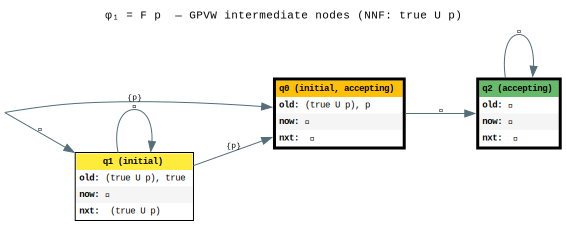

In [14]:
# ── φ₁ : F p  ("eventually p") ───────────────────────────────────────────────
show_gpvw(F(Var('p')), title='φ₁ = F p  — GPVW intermediate nodes (NNF: true U p)')

Formula: G p   NNF: (false R p)
Until sub-formulas in NNF: []

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(false R p), p}                          ∅       {(false R p)}


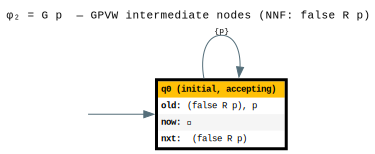

In [15]:
# ── φ₂ : G p  ("always p") ───────────────────────────────────────────────────
show_gpvw(G(Var('p')), title='φ₂ = G p  — GPVW intermediate nodes (NNF: false R p)')

Formula: (p U q)   NNF: (p U q)
Until sub-formulas in NNF: ['(p U q)']

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(p U q), q}                              ∅       ∅
q1     ✓              {(p U q), p}                              ∅       {(p U q)}
q2            ✓       ∅                                         ∅       ∅


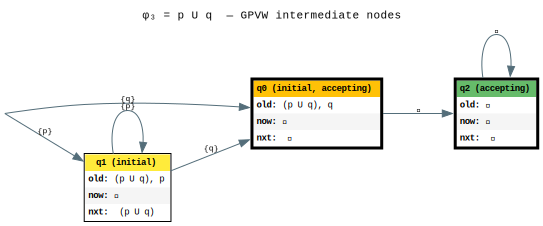

In [16]:
# ── φ₃ : p U q  ("p until q") ────────────────────────────────────────────────
show_gpvw(U(Var('p'), Var('q')), title='φ₃ = p U q  — GPVW intermediate nodes')

Formula: G F p   NNF: (false R (true U p))
Until sub-formulas in NNF: ['(true U p)']

Node   Init   Acc     old                                       now     nxt
------------------------------------------------------------------------------------------
q0     ✓      ✓       {(false R (true U p)), (true U p), p}     ∅       {(false R (true U p))}
q1     ✓              {(false R (true U p)), (true U p), true}  ∅       {(false R (true U p)), (true U p)}


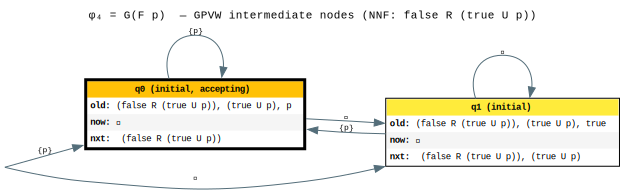

In [17]:
# ── φ₄ : G(F p)  ("p holds infinitely often") ────────────────────────────────
show_gpvw(G(F(Var('p'))), title='φ₄ = G(F p)  — GPVW intermediate nodes (NNF: false R (true U p))')

## 7. Destination proposition — `F(destination)` via intersection automaton

We add the proposition **`destination`** to node **67471** and verify the LTL formula
**φ = F(destination)** — *eventually reach the destination lane* — using the
automata-theoretic model-checking pipeline:

| Step | What happens |
|------|-------------|
| 1 | Extend `node_to_props` so that node `67471` carries `destination`. |
| 2 | Rebuild the Kripke model **with a self-loop on every node** (stuttering semantics). |
| 3 | Build the Büchi automaton `B` for `F(destination)` via `ltl_to_buchi_gpvw`. |
| 4 | Form the **product automaton** `M × B` via `kripke_buchi_product`. |
| 5 | Run **Tarjan SCC + emptiness check** on `M × B`; extract the lasso `(stem, cycle)`. |
| 6 | **Truncate before the repetitive part**: project `stem` back to Kripke states. |
| 7 | Visualize the Kripke model with the satisfying path highlighted. |

Propositions per state (with self-loops added):
  63215: ['lane']
  63216: ['fork', 'lane']
  67259: ['fork', 'lane']
  67282: ['lane']
  67471: ['destination', 'lane']
  68826: ['connector']
  69357: ['connector']
  69411: ['connector']
  69518: ['connector', 'ego']  [initial]
  70048: ['connector']
  70050: ['connector']
  70200: ['connector']


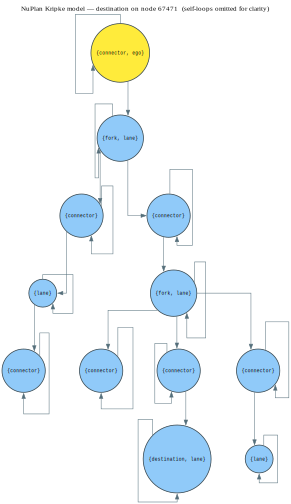

In [18]:
# ── Steps 1 & 2: 'destination' prop for node 67471 + self-loop on every node ────
from tutorials.buchi import kripke_buchi_product

DESTINATION_NODE = '67471'

def node_to_props_dest(node_id: str) -> set:
    props = set()
    props.add(object_types.get(node_id, 'unknown'))
    if node_id == ego_id:
        props.add('ego')
    if small_G.out_degree(node_id) > 1:
        props.add('fork')
    if node_id == DESTINATION_NODE:
        props.add('destination')
    return props

kripke_dest = KripkeModel()
for node in small_G.nodes():
    props = node_to_props_dest(node)
    if node == ego_id:
        kripke_dest.add_initial_state(node, props)
    else:
        kripke_dest.add_state(node, props)
for src, dst in small_G.edges():
    kripke_dest.add_transition(src, dst)
# Self-loops: every state can stutter (required for total transition relation)
for node in small_G.nodes():
    kripke_dest.add_transition(node, node)

print('Propositions per state (with self-loops added):')
for s in sorted(kripke_dest.states, key=str):
    marker = '  [initial]' if s in kripke_dest.initial_states else ''
    print(f'  {s}: {sorted(kripke_dest.labeling[s])}{marker}')

g = draw(kripke_dest,
         title='NuPlan Kripke model — destination on node 67471  (self-loops omitted for clarity)',
         node_propositions=node_to_props_dest,
         show_edge_labels=False, use_xlabels=False,
         initial_color='#ffeb3b',
         size='10,7', nodesep=0.7, ranksep=0.9)
display.SVG(g.pipe(format='svg'))

In [19]:
# ── Step 3: Büchi automaton for φ = F(destination) ──────────────────────────────
phi_dest = F(Var('destination'))
ba_dest  = ltl_to_buchi_gpvw(phi_dest)
print(f'F(destination)  →  {len(ba_dest.states)} states, '
      f'{sum(len(list(ba_dest.successors(s))) for s in ba_dest.states)} edges')

F(destination)  →  3 states, 7 edges


In [20]:
# ── Steps 4-6: product automaton M×B, Tarjan SCC, lasso extraction ──────────────

# Step 4: build the product automaton
product = kripke_buchi_product(kripke_dest, ba_dest)
print(f'Product M×B: {len(product.states)} states, '
      f'{sum(len(product.transitions.get(s, [])) for s in product.states)} transitions')
print(f'  initial:  {len(product.initial_states)}')
print(f'  accepting: {len(product.accepting_states)}')

# Step 5: Tarjan SCC + emptiness check — returns the state trace of the lasso
is_empty, prefix_states, cycle_states = product.check_emptiness_with_states()

if is_empty:
    print('\nF(destination) is NOT satisfied in this Kripke model.')
    kripke_path = None
else:
    # Step 6: project product states (s, q) → Kripke states, truncate before loop
    kripke_path = [s for s, _q in prefix_states]
    cycle_k     = [s for s, _q in cycle_states]

    print(f'\nLasso stem  (satisfying path, {len(kripke_path)-1} step(s)):')
    for i, s in enumerate(kripke_path):
        props = sorted(kripke_dest.labeling[s])
        tags  = []
        if s in kripke_dest.initial_states:          tags.append('initial')
        if 'destination' in kripke_dest.labeling[s]: tags.append('DESTINATION')
        tag = '  [' + ', '.join(tags) + ']' if tags else ''
        print(f'  step {i}: {s}  {props}{tag}')

    print(f'\nLasso cycle (truncated / not shown in path): {cycle_k}')
    print('  → self-loop at destination node (due to stutter self-loop)')

Product M×B: 36 states, 70 transitions
  initial:  2
  accepting: 24

Lasso stem  (satisfying path, 6 step(s)):
  step 0: 69518  ['connector', 'ego']  [initial]
  step 1: 67259  ['fork', 'lane']
  step 2: 70050  ['connector']
  step 3: 63216  ['fork', 'lane']
  step 4: 69411  ['connector']
  step 5: 67471  ['destination', 'lane']  [DESTINATION]
  step 6: 67471  ['destination', 'lane']  [DESTINATION]

Lasso cycle (truncated / not shown in path): ['67471', '67471']
  → self-loop at destination node (due to stutter self-loop)


Path: 69518 → 67259 → 70050 → 63216 → 69411 → 67471 → 67471


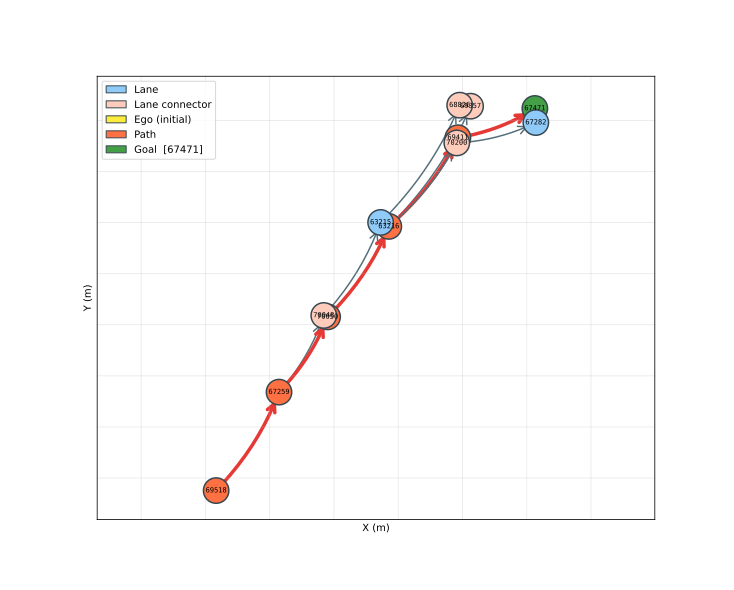

In [21]:
from tutorials.buchi.nuplan_graph import draw_nuplan_path

if kripke_path is None:
    print('No satisfying path — cannot visualize.')
else:
    print('Path: ' + ' → '.join(kripke_path))
    display.display(draw_nuplan_path(draw_G, pos, object_types, ego_id, kripke_path,
                     destination_node=DESTINATION_NODE,
                     goal_label=DESTINATION_NODE,
                     title='F(destination) — satisfying path highlighted on NuPlan subgraph'))

## 8. Two more LTL formulae on the NuPlan graph

Same pipeline as section 7 — reuse `kripke_dest` (12 states, self-loops, propositions: `lane`, `connector`, `ego`, `fork`, `destination`).

| # | Formula | Reading |
|---|---------|---------|
| A | `F(fork)` | The ego eventually reaches a road fork (a choice/decision point). |
| B | `F(lane ∧ ¬fork)` | The ego eventually reaches a plain lane — not a fork, not a connector. |

For each formula: build `B(φ)` via `ltl_to_buchi_gpvw`, form `M × B`, run Tarjan SCC emptiness check, project the lasso stem to Kripke states, and plot the witness path.

In [22]:
import IPython.display as display
from tutorials.buchi.nuplan_graph import draw_nuplan_path

def _plot_nuplan_path(path, goal_label, title):
    """Highlight a satisfying LTL witness path on the NuPlan subgraph."""
    if path is None:
        print(f'UNSAT — {title}')
        return
    print('Path: ' + ' → '.join(str(s) for s in path))
    display.display(draw_nuplan_path(draw_G, pos, object_types, ego_id, path,
                                     title=title, goal_label=goal_label))

F(fork)  →  3 states, 7 edges

Satisfying path (4 step(s)):
  step 0: 69518  ['connector', 'ego']  [initial]
  step 1: 67259  ['fork', 'lane']  [FORK]
  step 2: 70048  ['connector']
  step 3: 63215  ['lane']
  step 4: 68826  ['connector']
Path: 69518 → 67259 → 70048 → 63215 → 68826


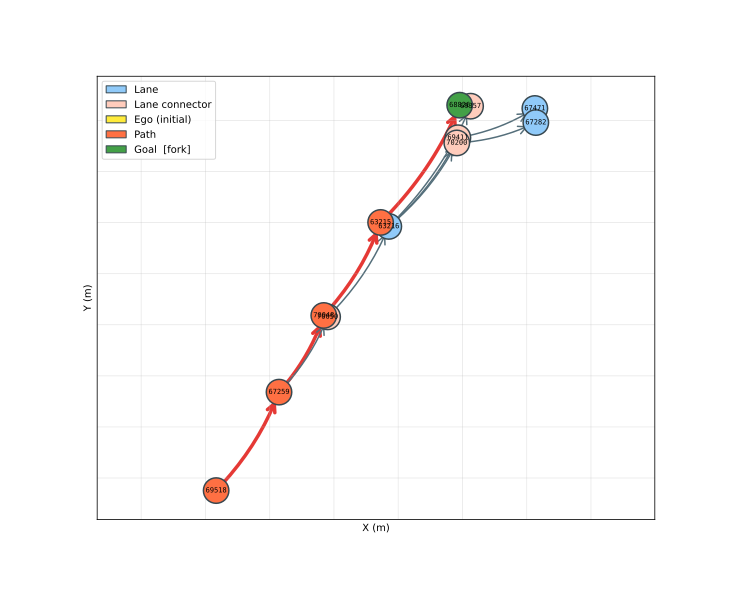

In [23]:
# φ_A = F(fork) — "eventually reach a road fork (decision point)"
phi_a = F(Var('fork'))
ba_a  = ltl_to_buchi_gpvw(phi_a)
print(f'F(fork)  →  {len(ba_a.states)} states, '
      f'{sum(len(list(ba_a.successors(s))) for s in ba_a.states)} edges')

product_a = kripke_buchi_product(kripke_dest, ba_a)
is_empty_a, prefix_a, _ = product_a.check_emptiness_with_states()
path_a = None if is_empty_a else [s for s, _q in prefix_a]

if path_a:
    print(f'\nSatisfying path ({len(path_a)-1} step(s)):')
    for i, s in enumerate(path_a):
        tags = (['initial'] if s in kripke_dest.initial_states else []) + \
               (['FORK'] if 'fork' in kripke_dest.labeling[s] else [])
        print(f'  step {i}: {s}  {sorted(kripke_dest.labeling[s])}' +
              (f'  [{", ".join(tags)}]' if tags else ''))

_plot_nuplan_path(path_a, 'fork', 'φ = F(fork) — satisfying path to first road fork')

F(lane ∧ ¬fork)  →  3 states, 13 edges

Satisfying path (6 step(s)):
  step 0: 69518  ['connector', 'ego']  [initial]
  step 1: 67259  ['fork', 'lane']
  step 2: 70050  ['connector']
  step 3: 63216  ['fork', 'lane']
  step 4: 69411  ['connector']
  step 5: 67471  ['destination', 'lane']  [GOAL]
  step 6: 67471  ['destination', 'lane']  [GOAL]
Path: 69518 → 67259 → 70050 → 63216 → 69411 → 67471 → 67471


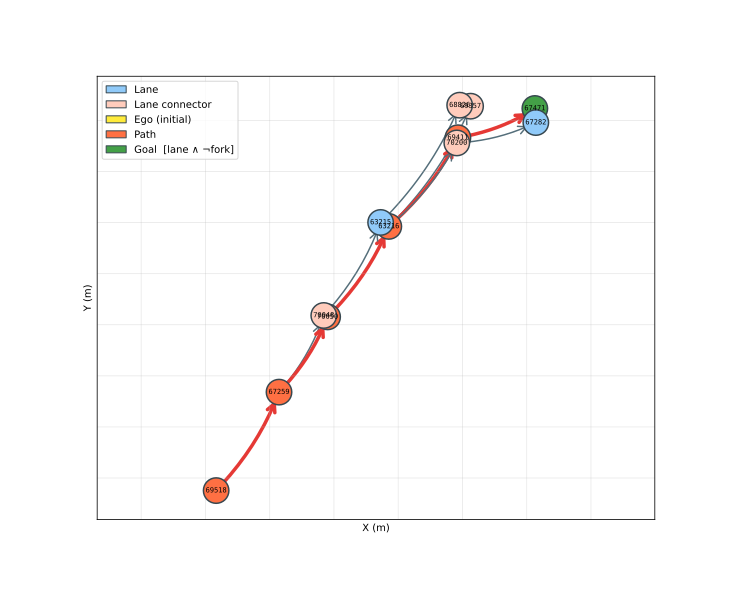

In [24]:
# φ_B = F(lane ∧ ¬fork) — "eventually reach a plain lane (not a fork, not a connector)"
from tutorials.buchi import And, Not

phi_b = F(And(Var('lane'), Not(Var('fork'))))
ba_b  = ltl_to_buchi_gpvw(phi_b)
print(f'F(lane ∧ ¬fork)  →  {len(ba_b.states)} states, '
      f'{sum(len(list(ba_b.successors(s))) for s in ba_b.states)} edges')

product_b = kripke_buchi_product(kripke_dest, ba_b)
is_empty_b, prefix_b, _ = product_b.check_emptiness_with_states()
path_b = None if is_empty_b else [s for s, _q in prefix_b]

if path_b:
    print(f'\nSatisfying path ({len(path_b)-1} step(s)):')
    for i, s in enumerate(path_b):
        tags = (['initial'] if s in kripke_dest.initial_states else []) + \
               (['GOAL'] if ('lane' in kripke_dest.labeling[s] and
                              'fork' not in kripke_dest.labeling[s]) else [])
        print(f'  step {i}: {s}  {sorted(kripke_dest.labeling[s])}' +
              (f'  [{", ".join(tags)}]' if tags else ''))

_plot_nuplan_path(path_b, 'lane ∧ ¬fork', 'φ = F(lane ∧ ¬fork) — path to a plain lane')

## 9. Larger subgraph: radius = 500 m, depth = 30 — F(destination) to node 67282

Same pipeline as section 7 but with a wider map search (`radius=500`) and a deeper BFS (`depth_limit=30`), yielding a larger Kripke model.  The destination is set to node **67282** — a plain lane segment reachable further along the road network.

| Parameter | Section 7 | Section 9 |
|-----------|-----------|-----------|
| `radius` | 200 m | 500 m |
| `depth_limit` | 10 | 30 |
| Destination node | 67471 | 67282 |

In [ ]:
# ── Load the larger subgraph ──────────────────────────────────────────────────
small_G_2, object_map_2, object_types_2, ego_id_2 = load_nuplan_subgraph(nuplan_map, ego_point, radius=500, depth_limit=30)
print(f"Subgraph: {small_G_2.number_of_nodes()} nodes, {small_G_2.number_of_edges()} edges")
print(f"Ego node: {ego_id_2}")
print("\nAll node IDs (type):")
for n in sorted(small_G_2.nodes(), key=str):
    marker = "  ← ego" if n == ego_id_2 else ""
    print(f"  {n}  ({object_types_2.get(n, 'unknown')}){marker}")

In [ ]:
from tutorials.buchi.nuplan_graph import nuplan_pos, draw_nuplan_subgraph

pos_2 = nuplan_pos(small_G_2, object_map_2)
draw_G_2 = small_G_2.subgraph(pos_2.keys()).copy()

draw_nuplan_subgraph(draw_G_2, pos_2, object_types_2, ego_id_2,
                     title='NuPlan subgraph (radius=500 m, depth=30) — ego neighbourhood',
                     figsize=(14, 11), node_size=450, arrowsize=12, font_size=5)

In [ ]:
# ── F(destination) check — destination = node 67282 ──────────────────────────
# Update DESTINATION_NODE_2 to any node ID printed in the cell above.
DESTINATION_NODE_2 = '67377'

def node_to_props_dest_2(node_id: str) -> set:
    props = set()
    props.add(object_types_2.get(node_id, 'unknown'))
    if node_id == ego_id_2:
        props.add('ego')
    if small_G_2.out_degree(node_id) > 1:
        props.add('fork')
    if node_id == DESTINATION_NODE_2:
        props.add('destination')
    return props

kripke_dest_2 = KripkeModel()
for node in small_G_2.nodes():
    props = node_to_props_dest_2(node)
    if node == ego_id_2:
        kripke_dest_2.add_initial_state(node, props)
    else:
        kripke_dest_2.add_state(node, props)
for src, dst in small_G_2.edges():
    kripke_dest_2.add_transition(src, dst)
for node in small_G_2.nodes():
    kripke_dest_2.add_transition(node, node)

phi_dest_2 = F(Var('destination'))
ba_dest_2  = ltl_to_buchi_gpvw(phi_dest_2)
product_2  = kripke_buchi_product(kripke_dest_2, ba_dest_2)
print(f'Product M×B: {len(product_2.states)} states, '
      f'{sum(len(product_2.transitions.get(s, [])) for s in product_2.states)} transitions')

is_empty_2, prefix_states_2, cycle_states_2 = product_2.check_emptiness_with_states()

if is_empty_2:
    print(f'\nF(destination={DESTINATION_NODE_2}) is NOT satisfied in this Kripke model.')
    kripke_path_2 = None
else:
    kripke_path_2 = [s for s, _q in prefix_states_2]
    print(f'\nLasso stem ({len(kripke_path_2)-1} step(s)):')
    for i, s in enumerate(kripke_path_2):
        tags = (['initial'] if s in kripke_dest_2.initial_states else []) + \
               (['DESTINATION'] if 'destination' in kripke_dest_2.labeling[s] else [])
        print(f'  step {i}: {s}  {sorted(kripke_dest_2.labeling[s])}' +
              (f'  [{", ".join(tags)}]' if tags else ''))

In [ ]:
import IPython.display as display
from tutorials.buchi.nuplan_graph import draw_nuplan_path

if kripke_path_2 is None:
    print('No satisfying path — cannot visualize.')
else:
    print('Path: ' + ' → '.join(kripke_path_2))
    display.display(draw_nuplan_path(draw_G_2, pos_2, object_types_2, ego_id_2, kripke_path_2,
                     destination_node=DESTINATION_NODE_2,
                     goal_label=DESTINATION_NODE_2,
                     title=f'F(destination={DESTINATION_NODE_2}) — satisfying path (radius=500 m, depth=30)',
                     figsize=(14, 11), node_size=550, arrowsize=12, font_size=5))